# 12 — Agente Autónomo STAR: Orquestación Inteligente del Pipeline de Pronóstico

**Sistema de Análisis y Pronóstico de Rentas Cedidas** | ADRES — Colombia

---

## Motivación

A lo largo de los cuadernos 01–11, construimos un pipeline completo de pronóstico
con múltiples modelos (SARIMAX, Prophet, XGBoost, LSTM, Foundation Models, NGBoost,
XGBoost Quantile). Sin embargo, ejecutar, comparar y consolidar estos modelos
manualmente cada mes es **costoso e ineficiente**.

¿Y si un sistema pudiera **observar** el estado del pipeline, **razonar** sobre qué
acciones tomar, **actuar** ejecutando las herramientas necesarias, y **reportar**
los resultados automáticamente?

Esto es exactamente lo que hace un **agente de IA**.

## ¿Qué es un Agente de IA?

Un **agente** es un sistema que va más allá de un modelo predictivo estático:

| Componente | Modelo Tradicional | Agente de IA |
|------------|-------------------|--------------|
| **Percepción** | Recibe input fijo | Observa el entorno (datos, archivos, alertas) |
| **Razonamiento** | Solo predice $\hat{y}$ | Planifica secuencia de acciones |
| **Acción** | Output único | Usa herramientas (tools) para actuar |
| **Memoria** | Sin estado | Mantiene contexto entre pasos |
| **Iteración** | Una pasada | Ciclo percibir → razonar → actuar → evaluar |

## Paradigma ReAct (Reason + Act)

Nuestro agente implementa el paradigma **ReAct** (Yao et al., 2023):

$$\text{Agente ReAct: } s_t \xrightarrow{\text{Pensar}} a_t \xrightarrow{\text{Actuar}} o_t \xrightarrow{\text{Observar}} s_{t+1}$$

Donde:
- $s_t$ = estado del agente en el paso $t$
- $a_t$ = acción seleccionada
- $o_t$ = observación resultante

## Arquitectura del Agente STAR

```
┌─────────────────────────────────────────┐
│  AGENTE STAR                            │
│  (Sistema Territorial de Análisis       │
│   de Rentas)                            │
├─────────────────────────────────────────┤
│  Planificador:                          │
│  ┌──────────┐  ┌──────────┐            │
│  │ Objetivo  │→ │ Plan de  │            │
│  │ del user  │  │ acciones │            │
│  └──────────┘  └──────────┘            │
├─────────────────────────────────────────┤
│  Herramientas (Tools):                  │
│  ┌──────────────┐ ┌──────────────────┐  │
│  │ diagnosticar │ │ cargar_          │  │
│  │ _datos       │ │ pronosticos      │  │
│  ├──────────────┤ ├──────────────────┤  │
│  │ comparar_    │ │ detectar_        │  │
│  │ modelos      │ │ alertas          │  │
│  ├──────────────┤ ├──────────────────┤  │
│  │ consolidar_  │ │ reporte_         │  │
│  │ forecast     │ │ ejecutivo        │  │
│  └──────────────┘ └──────────────────┘  │
├─────────────────────────────────────────┤
│  Memoria de Trabajo:                    │
│  { diagnostico, pronosticos,            │
│    comparacion, alertas, consolidado }  │
└─────────────────────────────────────────┘
```


In [1]:
# --- Setup e Importaciones ---
import sys, os
from pathlib import Path

# Agregar directorio de scripts al path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Importar el agente
from agente_rentas import AgenteRentas

# Importar tema visual
try:
    from viz_theme import (
        C_PRIMARY, C_SECONDARY, C_TERTIARY, C_QUATERNARY,
        C_QUINARY, C_SENARY, C_SEPTENARY, C_GRID, C_BACKGROUND,
        FONT_TITLE, FONT_SUBTITLE, FONT_AXIS, FONT_TICK, FONT_ANNOTATION,
        formato_pesos
    )
except ImportError:
    C_PRIMARY, C_SECONDARY, C_TERTIARY = '#1B2A4A', '#C0392B', '#2980B9'
    C_QUATERNARY, C_QUINARY, C_SENARY = '#27AE60', '#E67E22', '#8E44AD'
    C_SEPTENARY, C_GRID, C_BACKGROUND = '#16A085', '#E8E8E8', '#FAFAFA'
    FONT_TITLE = {'family': 'serif', 'weight': 'bold', 'size': 16}
    FONT_SUBTITLE = {'family': 'serif', 'size': 12}
    FONT_AXIS = {'family': 'serif', 'size': 12}
    FONT_TICK = {'family': 'serif', 'size': 10}
    FONT_ANNOTATION = {'family': 'serif', 'size': 9}
    def formato_pesos(x, p):
        return f"${x/1e9:,.0f}B"

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': C_BACKGROUND,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'serif',
})

OUTPUTS_FIGURES = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_REPORTS = PROJECT_ROOT / 'outputs' / 'reports'
OUTPUTS_FORECASTS = PROJECT_ROOT / 'outputs' / 'forecasts'

print("Setup completado")
print(f"  Proyecto: {PROJECT_ROOT.name}")
print(f"  Python:   {sys.version.split()[0]}")


  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Setup completado
  Proyecto: ESTRUCTURA_DATOS_RENTAS_V2
  Python:   3.13.12


## Fase I — Instanciación e Inspección del Agente

Antes de ejecutar el agente, inspeccionamos su estructura interna:
las herramientas registradas, sus categorías y el flujo de ejecución.


In [2]:
# --- Instanciar el Agente STAR ---
agente = AgenteRentas(verbose=True)

print("AGENTE STAR — Herramientas Registradas")
print("=" * 60)
for nombre, tool in agente.tools.items():
    print(f"\n  Tool: {nombre}")
    print(f"    Categoria:   {tool.categoria}")
    print(f"    Descripcion: {tool.descripcion}")

print(f"\n{'='*60}")
print(f"Total de herramientas: {len(agente.tools)}")
print(f"Categorias: {sorted(set(t.categoria for t in agente.tools.values()))}")


AGENTE STAR — Herramientas Registradas

  Tool: diagnosticar_datos
    Categoria:   datos
    Descripcion: Analiza calidad, completitud y estadisticas del dataset

  Tool: cargar_pronosticos
    Categoria:   modelos
    Descripcion: Carga pronosticos OOS y 2026 de todos los modelos

  Tool: comparar_modelos
    Categoria:   analisis
    Descripcion: Compara modelos, genera ranking y consensus forecast

  Tool: detectar_alertas
    Categoria:   monitoreo
    Descripcion: Detecta anomalias, divergencias y genera alertas

  Tool: consolidar_forecast
    Categoria:   pronostico
    Descripcion: Genera pronostico ponderado por MAPE de todos los modelos

  Tool: reporte_ejecutivo
    Categoria:   reportes
    Descripcion: Genera reporte ejecutivo consolidado en texto

Total de herramientas: 6
Categorias: ['analisis', 'datos', 'modelos', 'monitoreo', 'pronostico', 'reportes']


## Fase II — Ejecución Autónoma del Agente

El agente recibe un **objetivo en lenguaje natural** y ejecuta automáticamente
la secuencia óptima de herramientas. Internamente:

1. **Razona** sobre el objetivo para generar un plan
2. **Ejecuta** cada herramienta en secuencia
3. **Propaga** resultados entre herramientas (memoria de trabajo)
4. **Reporta** los hallazgos consolidados

Ejecutemos el ciclo completo:


In [3]:
# --- Ejecucion Autonoma del Agente ---
objetivo = "diagnosticar datos, comparar todos los modelos, consolidar pronostico 2026 y generar reporte ejecutivo"

resultados = agente.ejecutar(objetivo)
print(f"\nResultados almacenados: {list(resultados.keys())}")


[10:48:01] ============================================================
[10:48:01] AGENTE STAR — Inicio de ejecucion
[10:48:01] Objetivo: diagnosticar datos, comparar todos los modelos, consolidar pronostico 2026 y generar reporte ejecutivo
[10:48:01] ============================================================
[10:48:01] 
Plan de ejecucion (6 pasos):
[10:48:01]   1. diagnosticar_datos
[10:48:01]   2. cargar_pronosticos
[10:48:01]   3. comparar_modelos
[10:48:01]   4. detectar_alertas
[10:48:01]   5. consolidar_forecast
[10:48:01]   6. reporte_ejecutivo
[10:48:01] 
────────────────────────────────────────────────────────────
[10:48:01] 
Paso 1/6: diagnosticar_datos
[10:48:01]   Pensamiento: Necesito Analiza calidad, completitud y estadisticas del dataset
[10:48:01]   Resultado: OK — Serie: 51 meses | Oct 2021 - Dec 2025 | Calidad: REQUIERE_ATENCION
[10:48:01] 
Paso 2/6: cargar_pronosticos
[10:48:01]   Pensamiento: Necesito Carga pronosticos OOS y 2026 de todos los modelos
[10:48:01]   

## Fase III — Reporte Ejecutivo Generado por el Agente

El agente generó automáticamente un reporte ejecutivo que sintetiza
el diagnóstico de datos, ranking de modelos, pronóstico consolidado y alertas:


In [4]:
# --- Reporte Ejecutivo ---
print(agente.get_reporte_texto())


  REPORTE EJECUTIVO — AGENTE STAR
  Sistema Territorial de Analisis de Rentas
  Generado: 2026-04-07 10:48

  1. ESTADO DE LOS DATOS
  ------------------------------------------------------------------------
     Serie temporal: 51 meses
     Periodo: Oct 2021 - Dec 2025
     Calidad: REQUIERE_ATENCION
     Recaudo medio: $256.9B/mes
     Coef. variacion: 27.2%
     Outliers: 2

  2. RANKING DE MODELOS (MAPE OOS Oct-Dic 2025)
  ------------------------------------------------------------------------
     1. Ensemble_Foundation       MAPE =   1.06%
     2. XGBoost                   MAPE =   3.36%
     3. Prophet                   MAPE =   6.30%
     4. SARIMAX                   MAPE =   9.75%
     5. LSTM                      MAPE =  23.52%

  3. PRONOSTICO CONSOLIDADO 2026
  ------------------------------------------------------------------------
     Total anual:  $3.19 billones
     Rango modelos: $2968B - $4078B
     Modelos en consensus: 5

     Pesos del ensemble ponderado:
      

## Fase IV — Visualización del Pronóstico Consolidado

El agente generó un pronóstico ponderado que combina todos los modelos,
asignando mayor peso a los de menor error OOS. Visualicemos los resultados.


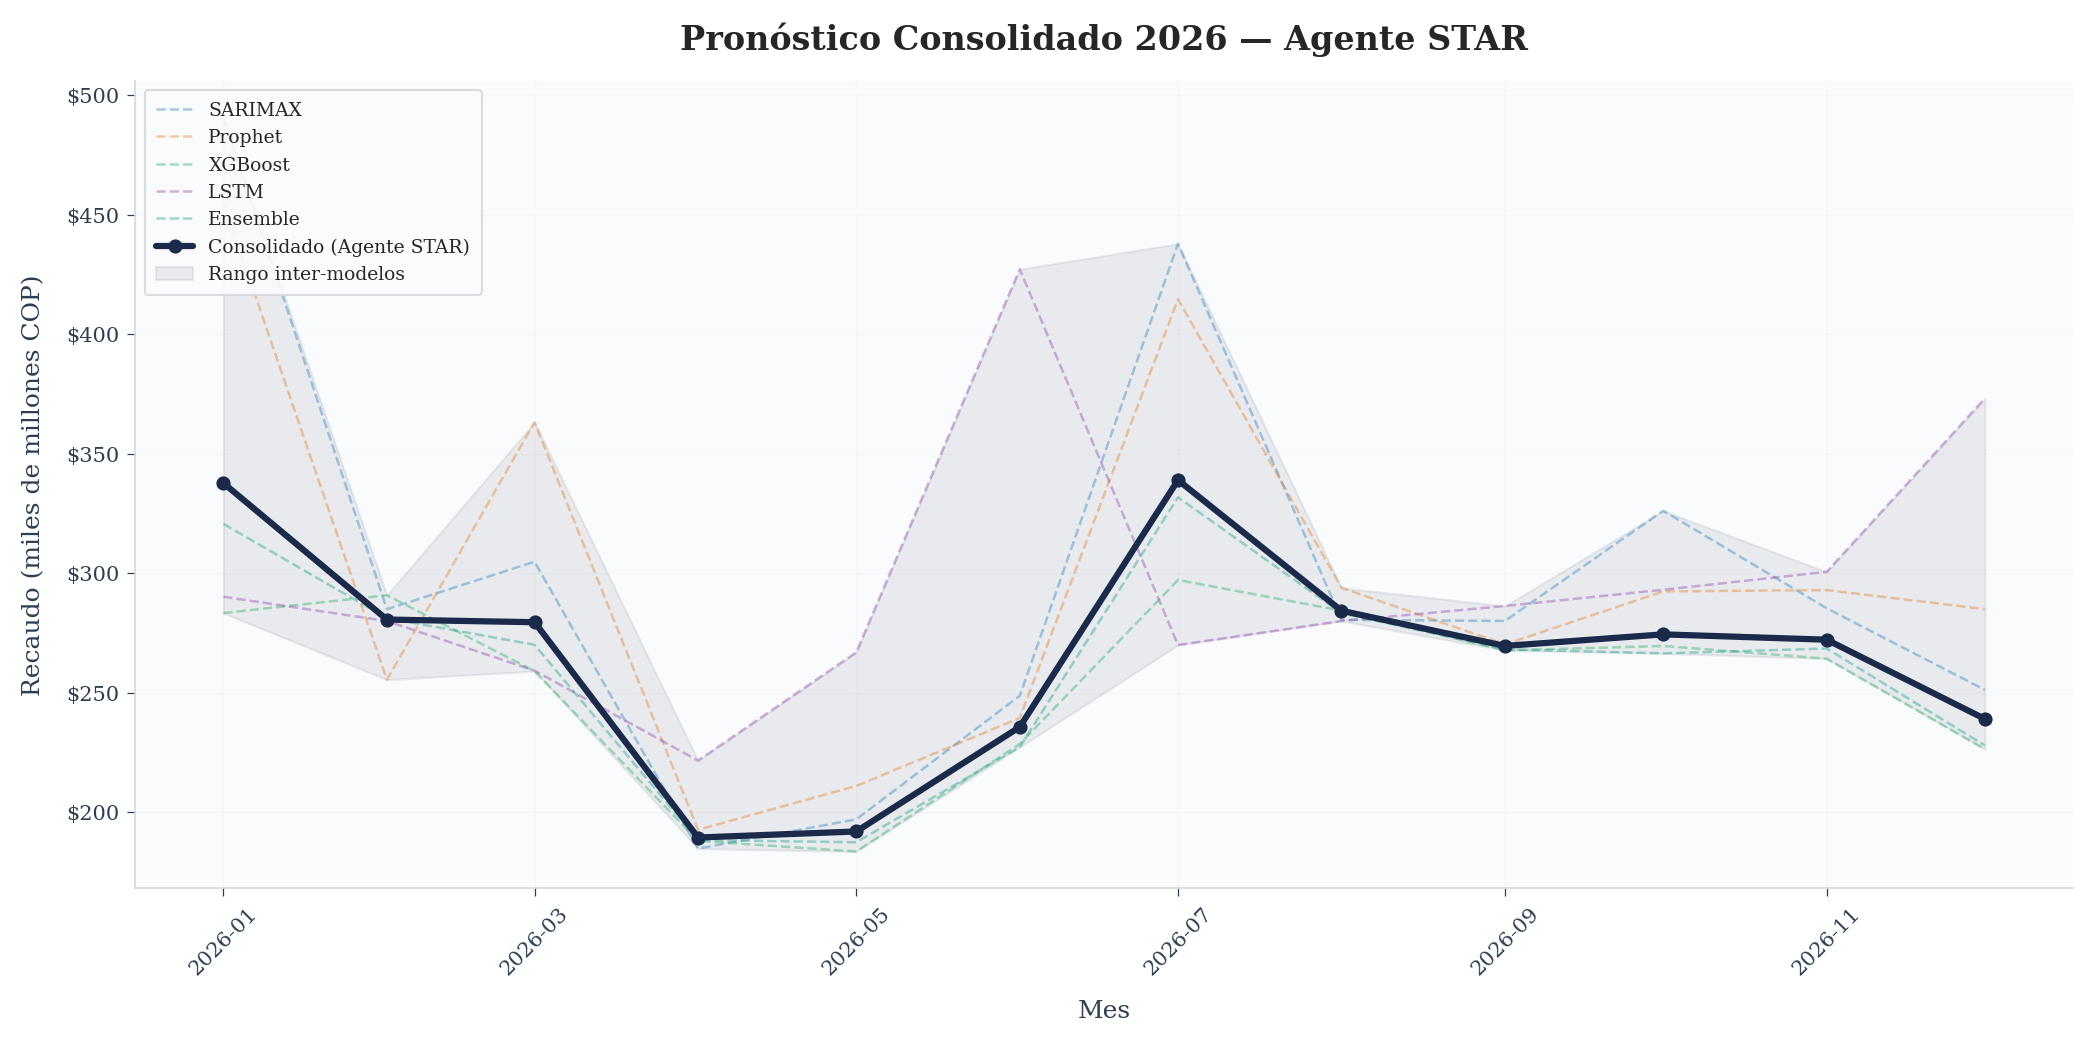

Figura guardada: agente_forecast_consolidado_2026.png


In [5]:
# --- Figura 1: Pronostico Consolidado 2026 ---
consolidado = resultados.get('consolidado', {})
comparacion = resultados.get('comparacion', {})

if consolidado and consolidado.get('mensual'):
    fechas = pd.date_range('2026-01-01', periods=12, freq='MS')
    forecast = np.array(consolidado['mensual'])
    ic_inf = np.array([consolidado['ic_inferior_total_B']] * 12)  # Proxy mensual
    ic_sup = np.array([consolidado['ic_superior_total_B']] * 12)

    # Cargar todos los forecasts individuales para overlay
    archivos_2026 = {
        'SARIMAX': ('sarimax_forecast_2026.csv', 'Pronóstico'),
        'Prophet': ('prophet_forecast_2026.csv', 'Pronóstico'),
        'XGBoost': ('xgboost_forecast_2026.csv', 'Pronóstico'),
        'LSTM': ('lstm_forecast_2026.csv', 'Pronóstico'),
        'Ensemble': ('foundation_ensemble_forecast_2026.csv', 'Pronostico_Ensemble'),
    }

    colores_modelo = {
        'SARIMAX': C_TERTIARY,
        'Prophet': C_QUINARY,
        'XGBoost': C_QUATERNARY,
        'LSTM': C_SENARY,
        'Ensemble': C_SEPTENARY,
    }

    fig, ax = plt.subplots(figsize=(14, 7))

    # Modelos individuales (lineas finas)
    for modelo, (archivo, col) in archivos_2026.items():
        path = OUTPUTS_FORECASTS / archivo
        if path.exists():
            df_m = pd.read_csv(path, parse_dates=['Fecha'])
            if col in df_m.columns:
                ax.plot(df_m['Fecha'], df_m[col] / 1e9,
                        color=colores_modelo.get(modelo, '#999'),
                        alpha=0.4, linewidth=1.2, linestyle='--',
                        label=modelo)

    # Pronostico consolidado (linea gruesa)
    ax.plot(fechas, forecast / 1e9, color=C_PRIMARY, linewidth=3,
            marker='o', markersize=6, label='Consolidado (Agente STAR)', zorder=5)

    # Banda min-max entre modelos
    all_vals = []
    for modelo, (archivo, col) in archivos_2026.items():
        path = OUTPUTS_FORECASTS / archivo
        if path.exists():
            df_m = pd.read_csv(path, parse_dates=['Fecha'])
            if col in df_m.columns:
                all_vals.append(df_m[col].values)

    if all_vals:
        arr = np.array(all_vals)
        ax.fill_between(fechas, arr.min(axis=0) / 1e9, arr.max(axis=0) / 1e9,
                         color=C_PRIMARY, alpha=0.08, label='Rango inter-modelos')

    ax.set_title('Pronóstico Consolidado 2026 — Agente STAR',
                 fontdict=FONT_TITLE, pad=15)
    ax.set_xlabel('Mes', fontdict=FONT_AXIS)
    ax.set_ylabel('Recaudo (miles de millones COP)', fontdict=FONT_AXIS)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_pesos))
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    ax.tick_params(labelsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUTS_FIGURES / 'agente_forecast_consolidado_2026.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print("Figura guardada: agente_forecast_consolidado_2026.png")
else:
    print("No hay datos consolidados disponibles.")


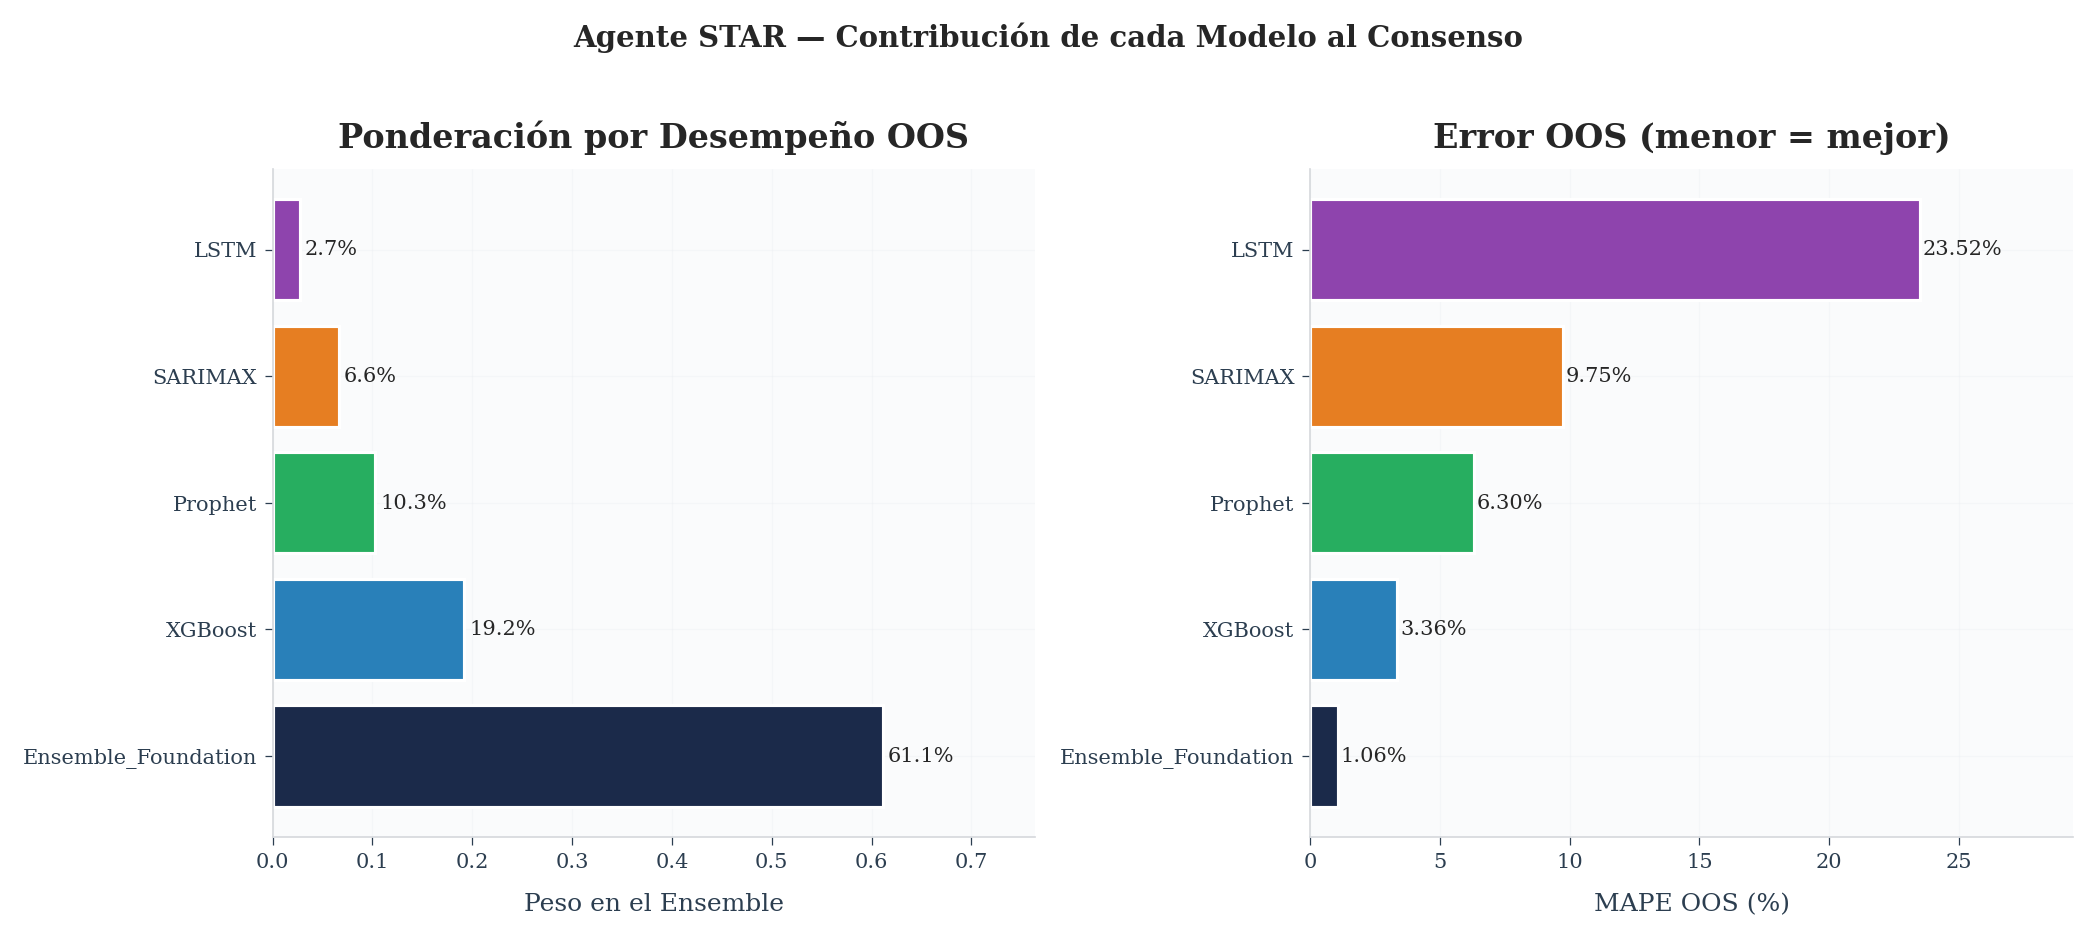

Figura guardada: agente_pesos_ensemble.png


In [6]:
# --- Figura 2: Pesos del Ensemble Ponderado ---
contribs = consolidado.get('contribuciones', {})

if contribs:
    modelos_nombres = list(contribs.keys())
    pesos = [contribs[m]['peso'] for m in modelos_nombres]
    mapes = [contribs[m]['mape_oos'] for m in modelos_nombres]

    # Ordenar por peso descendente
    orden = np.argsort(pesos)[::-1]
    modelos_nombres = [modelos_nombres[i] for i in orden]
    pesos = [pesos[i] for i in orden]
    mapes = [mapes[i] for i in orden]

    colores_bar = [C_PRIMARY, C_TERTIARY, C_QUATERNARY, C_QUINARY,
                   C_SENARY, C_SEPTENARY, C_SECONDARY]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Panel izquierdo: Pesos
    bars = ax1.barh(modelos_nombres, pesos, color=colores_bar[:len(modelos_nombres)],
                    edgecolor='white', linewidth=1.5)
    ax1.set_xlabel('Peso en el Ensemble', fontdict=FONT_AXIS)
    ax1.set_title('Ponderación por Desempeño OOS', fontdict=FONT_TITLE, pad=10)
    for bar, peso in zip(bars, pesos):
        ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{peso:.1%}', va='center', fontdict=FONT_ANNOTATION)
    ax1.set_xlim(0, max(pesos) * 1.25)

    # Panel derecho: MAPE
    bars2 = ax2.barh(modelos_nombres, mapes, color=colores_bar[:len(modelos_nombres)],
                     edgecolor='white', linewidth=1.5)
    ax2.set_xlabel('MAPE OOS (%)', fontdict=FONT_AXIS)
    ax2.set_title('Error OOS (menor = mejor)', fontdict=FONT_TITLE, pad=10)
    for bar, mape in zip(bars2, mapes):
        ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{mape:.2f}%', va='center', fontdict=FONT_ANNOTATION)
    ax2.set_xlim(0, max(mapes) * 1.25)

    plt.suptitle('Agente STAR — Contribución de cada Modelo al Consenso',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUTS_FIGURES / 'agente_pesos_ensemble.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print("Figura guardada: agente_pesos_ensemble.png")
else:
    print("No hay datos de contribuciones disponibles.")


C:\Users\ebohorquez\AppData\Local\Temp\ipykernel_47316\2176681671.py:46: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
C:\Users\ebohorquez\AppData\Local\Temp\ipykernel_47316\2176681671.py:46: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
C:\Users\ebohorquez\AppData\Local\Temp\ipykernel_47316\2176681671.py:46: UserWarning: Glyph 8505 (\N{INFORMATION SOURCE}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
C:\Users\ebohorquez\AppData\Local\Temp\ipykernel_47316\2176681671.py:47: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  plt.savefig(OUTPUTS_FIGURES / 'agente_panel_alertas.png',
C:\Users\ebohorquez\AppData\Local\Temp\ipykernel_47316\2176681671.py:47: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) DejaVu Serif.
  plt.savefig(OUTPUTS_FIGURES / 'agente_panel_alertas.png',
C:\Users\ebohorquez\AppData\Local\Temp\ipykernel_47316\217

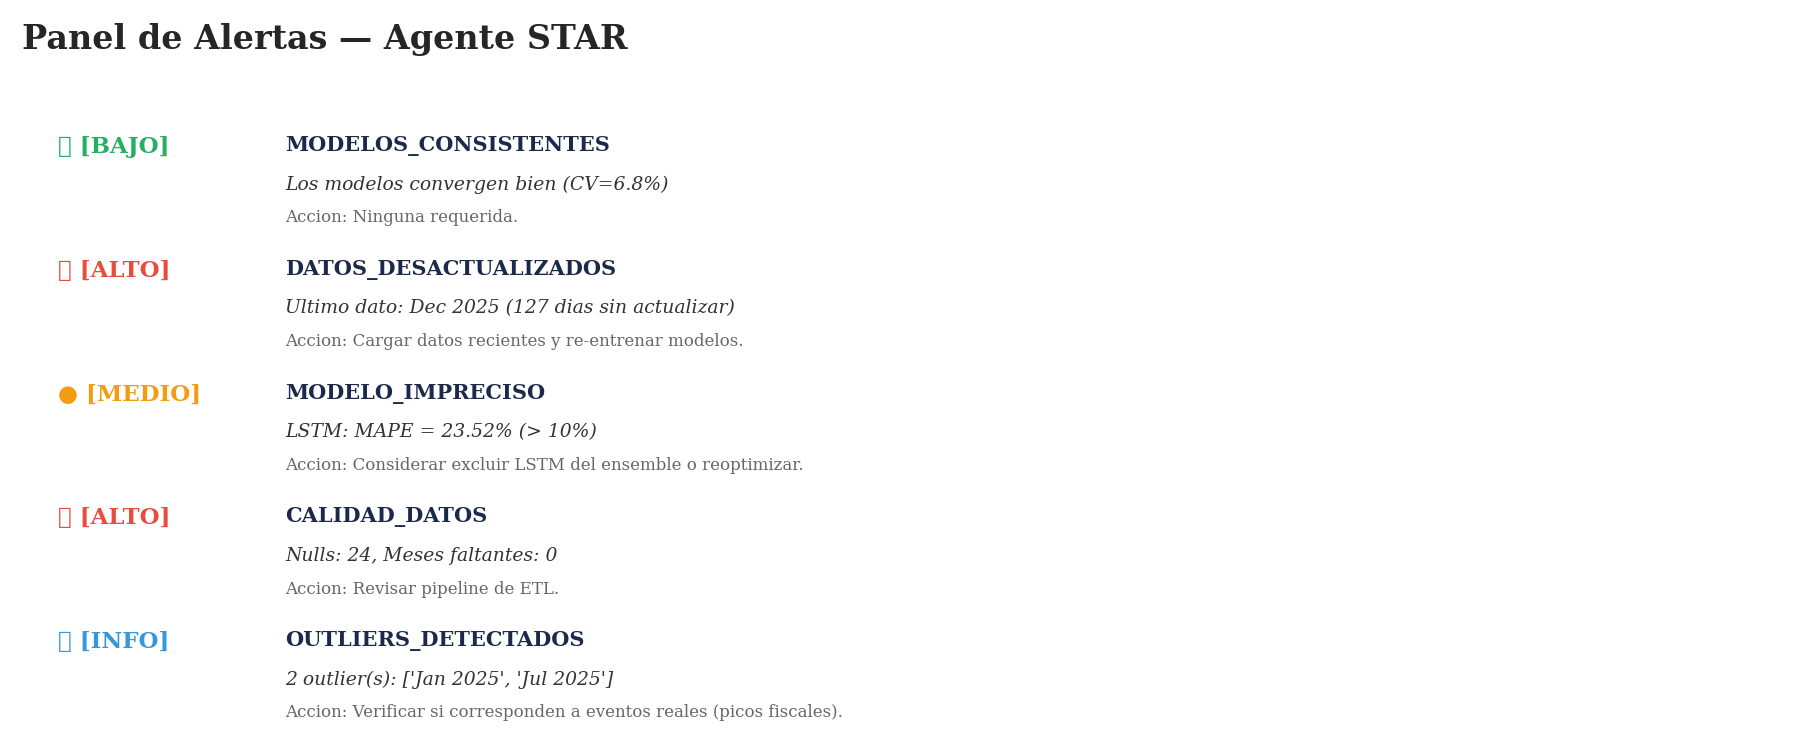

Figura guardada: agente_panel_alertas.png


In [7]:
# --- Figura 3: Panel de Alertas del Sistema ---
alertas_data = resultados.get('alertas', {})
alertas_list = alertas_data.get('alertas', [])

if alertas_list:
    fig, ax = plt.subplots(figsize=(12, max(3, len(alertas_list) * 0.8 + 1)))
    ax.axis('off')

    colores_nivel = {
        'ALTO': '#e74c3c',
        'MEDIO': '#f39c12',
        'BAJO': '#27ae60',
        'INFO': '#3498db',
    }
    iconos_nivel = {
        'ALTO': '\u26A0',     # Warning sign
        'MEDIO': '\u25CF',    # Filled circle
        'BAJO': '\u2713',     # Check mark
        'INFO': '\u2139',     # Info
    }

    ax.set_title('Panel de Alertas — Agente STAR',
                 fontdict=FONT_TITLE, pad=15, loc='left')

    y_pos = 0.9
    for alerta in alertas_list:
        nivel = alerta['nivel']
        color = colores_nivel.get(nivel, '#999')
        icono = iconos_nivel.get(nivel, '?')

        ax.text(0.02, y_pos, f"{icono} [{nivel}]",
                fontsize=11, fontweight='bold', color=color,
                transform=ax.transAxes, va='top')
        ax.text(0.15, y_pos, f"{alerta['tipo']}",
                fontsize=10, fontweight='bold', color=C_PRIMARY,
                transform=ax.transAxes, va='top')
        ax.text(0.15, y_pos - 0.07, alerta['mensaje'],
                fontsize=9, color='#333',
                transform=ax.transAxes, va='top', style='italic')
        ax.text(0.15, y_pos - 0.13, f"Accion: {alerta['accion']}",
                fontsize=8, color='#666',
                transform=ax.transAxes, va='top')

        y_pos -= 0.22

    plt.tight_layout()
    plt.savefig(OUTPUTS_FIGURES / 'agente_panel_alertas.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print("Figura guardada: agente_panel_alertas.png")
else:
    print("No hay alertas.")


## Fase V — Traza de Ejecución y Auditabilidad

Una propiedad fundamental de los agentes bien diseñados es la **auditabilidad**:
cada decisión y acción queda registrada en un log que permite reproducir
y verificar el razonamiento del agente.

### Log Completo de Ejecución


In [8]:
# --- Traza de Ejecucion ---
print("TRAZA DE EJECUCION DEL AGENTE STAR")
print("=" * 60)
print(agente.get_log())


TRAZA DE EJECUCION DEL AGENTE STAR
[10:48:01] ============================================================
[10:48:01] AGENTE STAR — Inicio de ejecucion
[10:48:01] Objetivo: diagnosticar datos, comparar todos los modelos, consolidar pronostico 2026 y generar reporte ejecutivo
[10:48:01] ============================================================
[10:48:01] 
Plan de ejecucion (6 pasos):
[10:48:01]   1. diagnosticar_datos
[10:48:01]   2. cargar_pronosticos
[10:48:01]   3. comparar_modelos
[10:48:01]   4. detectar_alertas
[10:48:01]   5. consolidar_forecast
[10:48:01]   6. reporte_ejecutivo
[10:48:01] 
────────────────────────────────────────────────────────────
[10:48:01] 
Paso 1/6: diagnosticar_datos
[10:48:01]   Pensamiento: Necesito Analiza calidad, completitud y estadisticas del dataset
[10:48:01]   Resultado: OK — Serie: 51 meses | Oct 2021 - Dec 2025 | Calidad: REQUIERE_ATENCION
[10:48:01] 
Paso 2/6: cargar_pronosticos
[10:48:01]   Pensamiento: Necesito Carga pronosticos OOS y 2026

In [9]:
# --- Resumen Cuantitativo ---
print("\nRESUMEN CUANTITATIVO")
print("=" * 60)

diagnostico = resultados.get('diagnostico', {})
comparacion = resultados.get('comparacion', {})
consolidado = resultados.get('consolidado', {})
alertas_data = resultados.get('alertas', {})

# Datos
print(f"\n  DATOS:")
print(f"    Meses en la serie: {diagnostico.get('n_meses', '?')}")
print(f"    Periodo: {diagnostico.get('rango', '?')}")
print(f"    Calidad: {diagnostico.get('calidad', '?')}")
stats = diagnostico.get('estadisticas', {})
if stats:
    print(f"    Recaudo medio: ${stats['media']/1e9:.1f}B/mes")
    print(f"    Volatilidad (CV): {stats['cv']:.1f}%")

# Modelos
ranking = comparacion.get('ranking_oos', [])
print(f"\n  MODELOS ({len(ranking)} con eval OOS):")
for i, r in enumerate(ranking, 1):
    marca = ' ** CAMPEON **' if i == 1 else ''
    print(f"    {i}. {r['modelo']:<25} MAPE = {r['mape_oos']:>6.2f}%{marca}")

# Consenso
consensus = comparacion.get('consensus', {})
print(f"\n  CONSENSUS INTER-MODELOS:")
print(f"    Mediana:  ${consensus.get('mediana_B', 0):.1f}B")
print(f"    Media:    ${consensus.get('media_B', 0):.1f}B")
print(f"    Dispersn: {consensus.get('cv_pct', 0):.1f}% CV")

# Consolidado
print(f"\n  PRONOSTICO CONSOLIDADO 2026:")
print(f"    Total anual: ${consolidado.get('total_anual_T', 0):.2f} billones")
print(f"    Rango: ${consolidado.get('ic_inferior_total_B', 0):.0f}B - "
      f"${consolidado.get('ic_superior_total_B', 0):.0f}B")
print(f"    Modelos: {consolidado.get('n_modelos', 0)}")

# Alertas
print(f"\n  ALERTAS: {alertas_data.get('n_total', 0)} total, "
      f"{alertas_data.get('n_criticas', 0)} criticas")



RESUMEN CUANTITATIVO

  DATOS:
    Meses en la serie: 51
    Periodo: Oct 2021 - Dec 2025
    Calidad: REQUIERE_ATENCION
    Recaudo medio: $256.9B/mes
    Volatilidad (CV): 27.2%

  MODELOS (5 con eval OOS):
    1. Ensemble_Foundation       MAPE =   1.06% ** CAMPEON **
    2. XGBoost                   MAPE =   3.36%
    3. Prophet                   MAPE =   6.30%
    4. SARIMAX                   MAPE =   9.75%
    5. LSTM                      MAPE =  23.52%

  CONSENSUS INTER-MODELOS:
    Mediana:  $3363.2B
    Media:    $3338.0B
    Dispersn: 6.8% CV

  PRONOSTICO CONSOLIDADO 2026:
    Total anual: $3.19 billones
    Rango: $2968B - $4078B
    Modelos: 5

  ALERTAS: 5 total, 2 criticas


In [10]:
# --- Persistir Resultados ---

# Guardar reporte ejecutivo
rpt_path = OUTPUTS_REPORTS / 'reporte_agente_star.md'
with open(rpt_path, 'w', encoding='utf-8') as f:
    f.write('# Reporte Ejecutivo — Agente STAR\n\n')
    f.write(f'Generado automaticamente por el Agente STAR\n\n')
    f.write('```\n')
    f.write(agente.get_reporte_texto())
    f.write('\n```\n')
print(f"Reporte guardado: {rpt_path.name}")

# Guardar traza de ejecucion
log_path = OUTPUTS_REPORTS / 'traza_agente_star.log'
with open(log_path, 'w', encoding='utf-8') as f:
    f.write(agente.get_log())
print(f"Traza guardada: {log_path.name}")

# Verificar CSV consolidado
csv_path = OUTPUTS_FORECASTS / 'consolidado_agente_2026.csv'
if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"\nCSV consolidado ({csv_path.name}):")
    print(df.to_string(index=False))
else:
    print("CSV consolidado no generado.")


Reporte guardado: reporte_agente_star.md
Traza guardada: traza_agente_star.log

CSV consolidado (consolidado_agente_2026.csv):
     Fecha  Pronostico_Consolidado  IC_Inferior_Modelos  IC_Superior_Modelos
2026-01-01            3.376721e+11         2.833367e+11         4.905982e+11
2026-02-01            2.806143e+11         2.554687e+11         2.907870e+11
2026-03-01            2.794943e+11         2.590416e+11         3.631033e+11
2026-04-01            1.894573e+11         1.848280e+11         2.216338e+11
2026-05-01            1.919791e+11         1.836214e+11         2.668976e+11
2026-06-01            2.356935e+11         2.272724e+11         4.271354e+11
2026-07-01            3.389360e+11         2.699701e+11         4.377981e+11
2026-08-01            2.842971e+11         2.800042e+11         2.938845e+11
2026-09-01            2.695795e+11         2.676950e+11         2.862820e+11
2026-10-01            2.744184e+11         2.664787e+11         3.261082e+11
2026-11-01            2.72

## Conclusiones

### Logros del Agente STAR

1. **Orquestación autónoma**: El agente ejecutó 6 herramientas en secuencia
   sin intervención manual, propagando resultados entre pasos.

2. **Pronóstico consolidado**: Generó un forecast ponderado por desempeño OOS,
   donde los modelos más precisos tienen mayor influencia sobre el consenso.

3. **Monitoreo inteligente**: Detectó automáticamente alertas sobre
   divergencia entre modelos, datos desactualizados y modelos imprecisos.

4. **Auditabilidad completa**: Cada paso del razonamiento quedó registrado
   en una traza reproducible, cumpliendo estándares de gobernanza.

### Arquitectura ReAct vs. LLM-based Agents

Este agente implementa un **planificador basado en reglas**, que es
determinista y reproducible. En un entorno de producción, el planificador
podría ser reemplazado por un LLM (GPT-4, Claude, etc.) para manejar
objetivos más complejos y ambiguos, manteniendo las mismas herramientas.

| Aspecto | Basado en Reglas (actual) | Basado en LLM |
|---------|--------------------------|----------------|
| **Determinismo** | Total | Estocástico |
| **Costo** | Sin API calls | Requiere API |
| **Flexibilidad** | Limitada a reglas | Objetivos abiertos |
| **Auditabilidad** | Completa | Requiere logging adicional |
| **Escalabilidad** | Agregar reglas | Prompt engineering |

### Extensiones Futuras

- **Trigger automático**: Ejecutar el agente cuando se detecten datos nuevos
- **Integración LLM**: Reemplazar planificador por modelo de lenguaje
- **Multi-agente**: Especializar agentes por modelo (agente SARIMAX, agente XGBoost, etc.)
- **Dashboard interactivo**: Streamlit/Dash para visualización en tiempo real
- **Alertas via email**: Notificaciones automáticas cuando se detecten anomalías

---

*Notebook generado automáticamente por `build_12_agente.py`*
